## Imports

In [4]:
from qsopt import * 
import numpy as np
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

## Define experimental parameters

In [5]:
gm = 0.03 * 2 * np.pi
inverse_pulse_width = 0.1 * gm

# Define custom physical constants
custom_constants = PhysicalConstants(
    chi = 0.5 * gm,                    # Dispersive coupling
    photon_cavity_coupling = gm,  # Photon-cavity coupling
    inverse_pulse_width = 0.1 * gm      # Inverse pulse width
)

# Define custom system dimensions
custom_dims = SystemDimensions(
    cavity_levels=2,
    qubit_levels=2,
    field_levels=2
)

# Define measurement protocol
custom_measurement = MeasurementProtocol(
    measurement_times = None,  # Use default measurement times
    initial_time=-5.0/inverse_pulse_width,
    final_time=5.0/inverse_pulse_width,
    time_interval=5.0/inverse_pulse_width,
    initial_time_uncertainty=2.0/inverse_pulse_width
)

# Define initial state configuration (SINGLE_PHOTON)
initial_state = InitialStateConfig(
    state_type=InitialStateType.SINGLE_PHOTON
)

# Define noise configuration
noise_config = NoiseConfiguration(
    depolarizing = 0.001,  
    dephasing = 0.001,      
    relaxation = 0.001
)

# Create parameters with custom configuration
exp_parameters = ExperimentalParameters(
    physical_constants=custom_constants,
    system_dims=custom_dims,
    measurement=custom_measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_parameters)

SYSTEM DIMENSIONS
  Cavity levels:             2
  Qubit levels:              2
  Field levels:              2
  Total dimension:           8
PHYSICAL CONSTANTS
  Chi:                    0.0942
  Photon cavity coupling: 0.1885
  Inverse pulse width:    0.0188
MEASUREMENT PROTOCOL
  Mode:                 Interval-based
  Initial time:         -265.2582
  Final time:           265.2582
  Time interval:        265.2582
  Number of measurements:      3
  Computed times:       [-265.25823848649225, 0.0, 265.25823848649225]
  Initial time uncertainty: 106.1033
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:      0.0010
  Dephasing rate:         0.0010
  Relaxation rate:        0.0010
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## Optional, plot pulse shape

Pulse shape plot saved to: pulse_shape.png


C:\Users\simon\AppData\Local\Temp\ipykernel_18216\3012061328.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


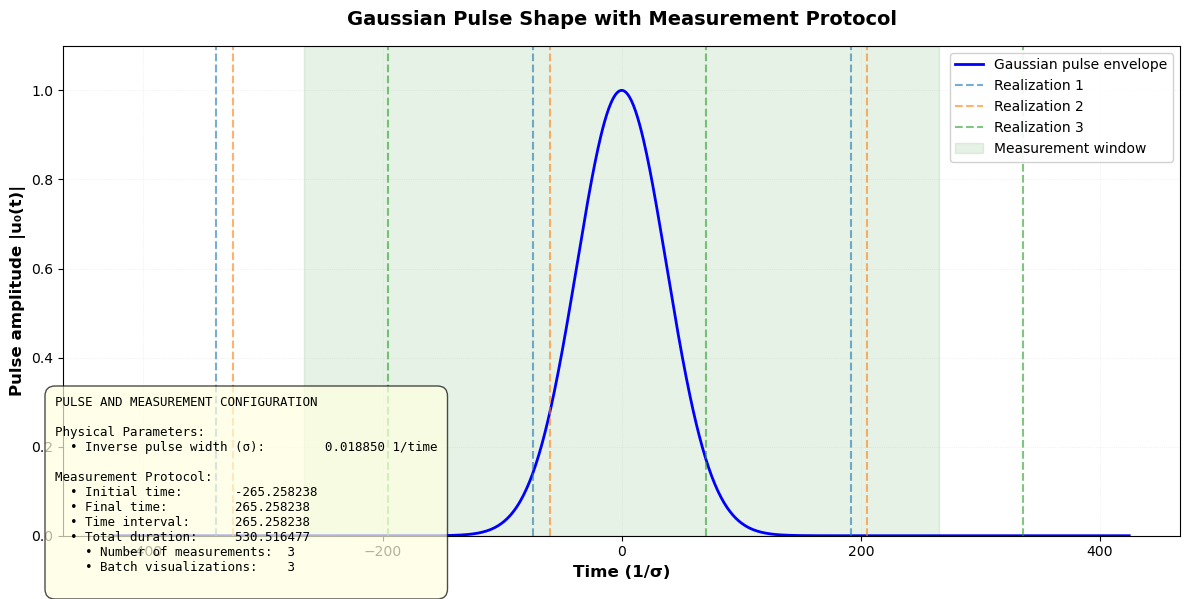

In [6]:
from qsopt.utils.visualization import plot_pulse_shape_with_measurements

fig = plot_pulse_shape_with_measurements(
    exp_params=exp_parameters,
    save_path='pulse_shape.png',
    batch_size=3
)
fig.show()

## Define trainable parameters

In [7]:
parameters = TrainableParameters()
parameters.add_rotation_angles(['ry1', 'ry2'], [np.pi/2, -np.pi/2], optimizer=optax.sgd(0.5))

print(parameters)

Trainable Parameters: 2
  Rotation Angles:
    ry1: 1.5708 rad (90.00°)
    ry2: -1.5708 rad (-90.00°)


## Define experiment

In [8]:
experiment = SingleQubitExperiment(exp_parameters, parameters)

## Test Single Simulation

In [9]:
results = experiment.run_simulation()
print(results)

MODE: Single Simulation
  Current Parameters:
     ry1: 1.570796 rad (90.00°)
     ry2: -1.570796 rad (-90.00°)
  Detection Probabilities:
     P(with photon):    0.780466
     P(without photon): 0.536414
     Contrast:          0.244052


## Run Optimization

In [ ]:


# The experiment automatically uses its built-in callback (saves every epoch by default)
history = experiment.optimize(
    theta_init=[1.1, -1.2],
    num_steps=70,
    verbose=True,
    batch_size=5,
    tolerance=1e-7
)

Configuration:
    Max iterations: 70
    Batch size: 5
    Convergence tolerance: 1.00e-07
    Initial rotation parameters: ry1=1.100 rad, ry2=-1.200 rad
    Optimizer: GradientTransformationExtraArgs
    Measurement uncertainty: ±106.103
Step  ry1         ry2         Contrast    Grad Norm
----------------------------------------------------------------------
[-0.10782437  0.04043351]
0     1.100000    -1.200000   0.218650    1.15e-01    
[-0.09435095  0.03896325]
[-0.08243708  0.03704349]
[-0.07198278  0.03485913]
[-0.06283989  0.03255075]
[-0.05480057  0.03010649]
[-0.04751415  0.02734674]
[-0.04148551  0.02503358]
[-0.03622383  0.02279155]
[-0.03193861  0.02108031]
[-0.0278614   0.01895738]
10    1.415699    -1.355104   0.244954    3.37e-02    
[-0.02451008  0.01729047]
[-0.02130404  0.01526373]
[-0.01877112  0.01388009]
[-0.01658371  0.01265915]
[-0.01456901  0.01132328]
[-0.01277147  0.01004506]
[-0.01124262  0.00898816]
[-0.0098658   0.00794158]
[-0.0087558   0.00725246]
[-0.007

In [18]:
print(history)

MODE: Optimization
     Total iterations: 70
     Best epoch:        70
     Converged: False
     Final gradient norm: 3.222485e-05
  Best Parameters:
     ry1: 1.531965 rad (87.78°)
     ry2: -1.445559 rad (-82.82°)
  Detection Probabilities:
     P(with photon):    0.766109
     P(without photon): 0.519782
     Contrast:          0.246327


## Visualization Dashboard

Dashboard saved to: results/opt_dashboard.pdf


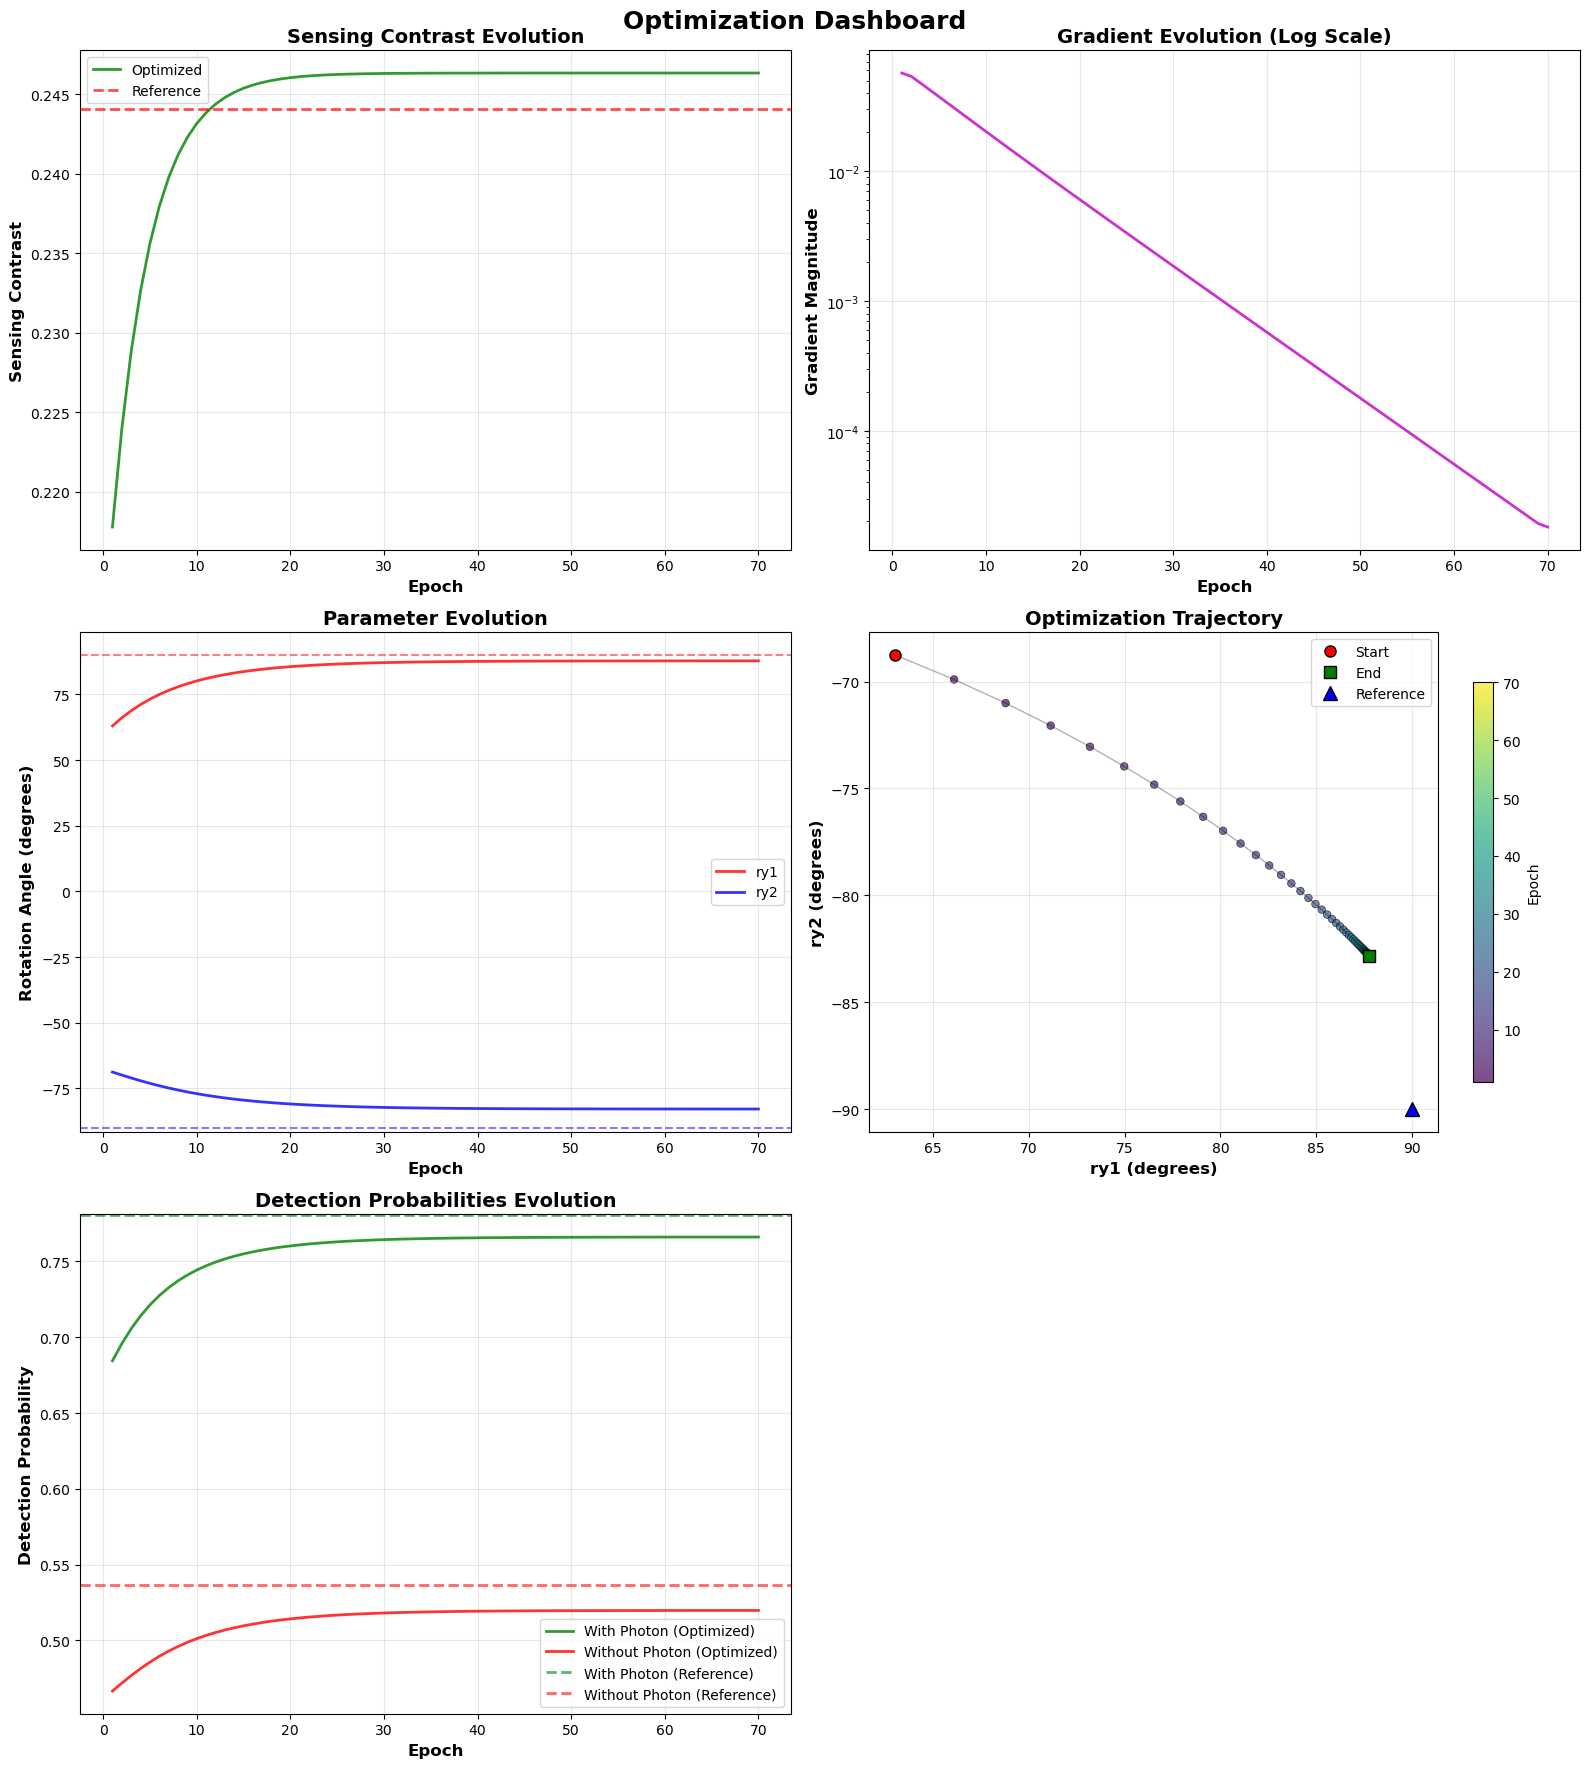

In [24]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history,
    reference_callback=results,
    show_contrast=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=True,
    show_probabilities=True,
    save_path='results/opt_dashboard.pdf'  # Save to file
)

plt.show()

### Dashboard Without Reference

Plot without a reference callback:

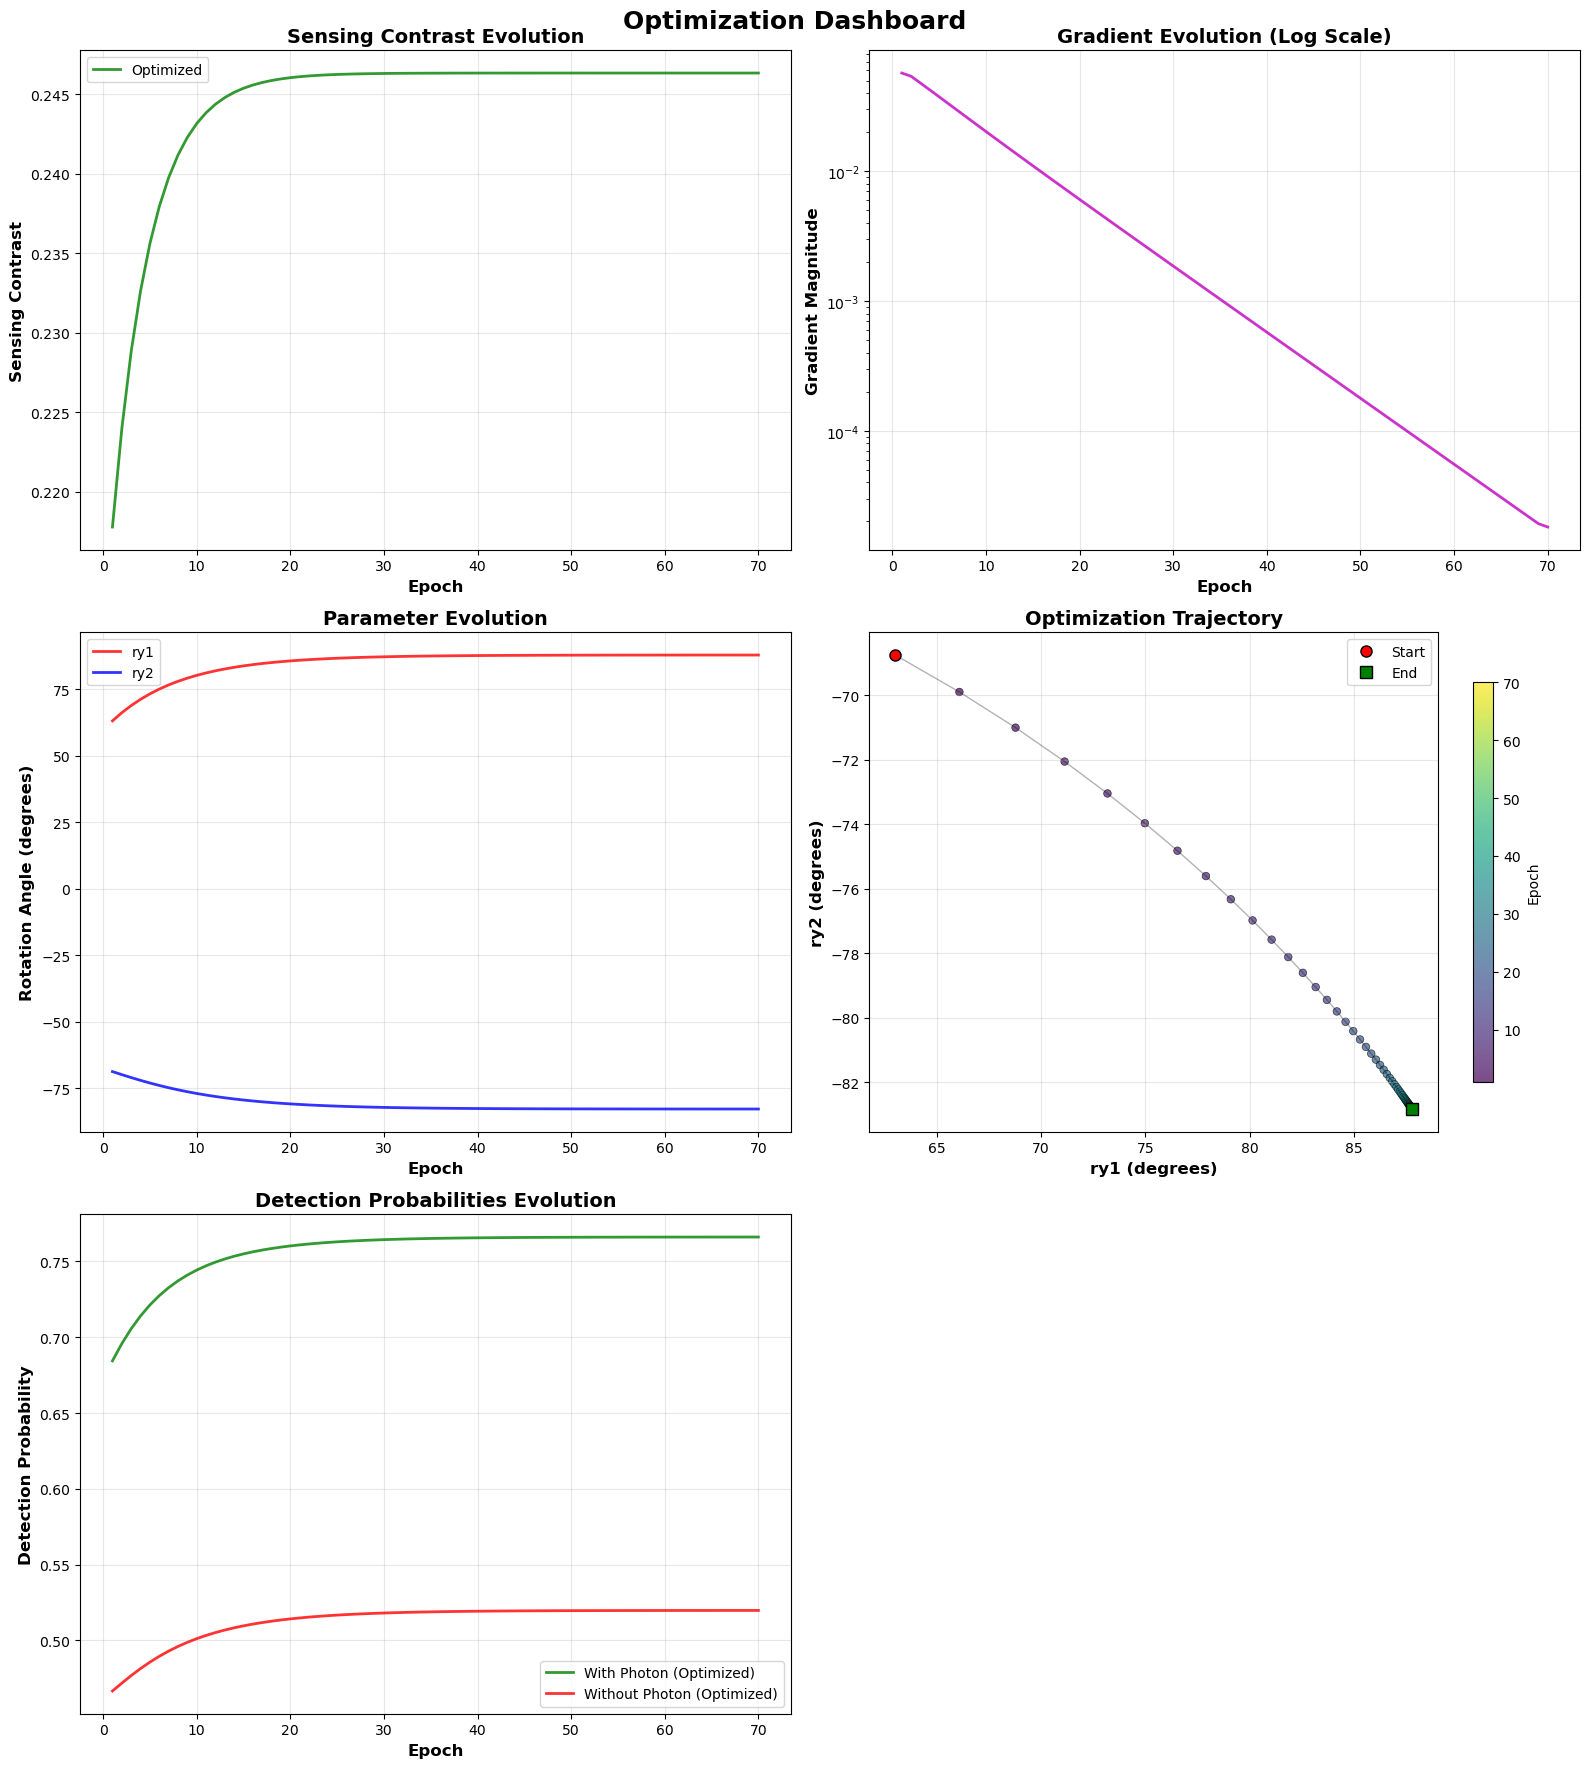

In [22]:
# Dashboard without reference (no benchmark lines)
fig = plot_optimization_dashboard(
    optimization_callback=history,
    show_contrast=True,
    show_parameters=True,
    show_trajectory=True,
    show_probabilities=True,
    save_path=None  # Don't save, just display
)

plt.show()